# Tutorial: Plotting

This notebook demonstrates the `TrackingExperiment.plot()` method for all
supported `plot_type` values and shows how to configure margin axes, color
maps, axis limits, and saccade-specific visualisations.

**Prerequisite**: run `tutorial_query.ipynb` first so that saccade tables are
saved alongside the `.zarr` stores — or just run the detection cell in
Section 1 below.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 100

REPO_ROOT = Path('..').resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from magno_tracker.tracking import TrackingTrial, TrackingExperiment

H5_DIR = REPO_ROOT / 'h5_files'

## 1  Setup — load trials and detect saccades

We use fly 1, all three trial numbers (so the heading variable has some natural
variability), loading condition 1 and condition 2 for a two-column grid.

In [2]:
RERUN = True
# Load cond1 and cond2 for fly 1 — all 3 trial numbers
files = sorted(H5_DIR.glob('*_pcf_*.h5'))
trials = [TrackingTrial(str(f)) for f in files]
trials = [t for t in trials if t.load_success]

exp = TrackingExperiment.__new__(TrackingExperiment)
exp.trials = trials
print(f'Loaded {len(exp.trials)} trials')
if RERUN:
    # some of the folders have to be rotated because the camera changed ourientation 
    VAR = 'body_angle'
    headings = exp.query(output=VAR, same_size=False)
    # for arr in headings:
    #     arr -= np.pi/2
    #     arr[arr < -np.pi] += 2*np.pi
    folders = exp.query(output='original_folder')
    # for folders 
    folders_to_rotate = ['NewControl\\PCF_FH\\vid_Angles', 'NewControl\\PCF_SD\\vid_Angles']
    include = np.isin(folders, folders_to_rotate)
    for included, arr in zip(include, headings):
        if included:
            arr += np.pi
            arr[arr > np.pi] -= 2*np.pi
    # store the new headings
    # exp.add_dataset(VAR + "_corrected", headings) 
    # make a variable for the distance from the odor plume, which is at +/- pi -- this means we want to add pi and then wrap it
    # headings = exp.query(output=VAR , same_size=False)
    # for heading in headings:
    #     heading += np.pi
    #     heading[heading > np.pi] -= 2 * np.pi
    # add the new dataset
    num_frames = exp.query(output='num_frames')
    diff_shapes = [num_frames[i][0] != len(headings[i][0]) for i in range(len(num_frames))]
    # for any that have a different number of frames, let's force them to match
    for i, diff in enumerate(diff_shapes):
        if diff:
            print(f"Trial {i} has {num_frames[i][0]} frames but {len(headings[i][0])} heading values. Reshaping to match.")
            headings[i] = np.resize(headings[i], (headings[i].shape[0], num_frames[i][0]))
    exp.add_dataset("odor displacement", headings)
    # Run saccade detection (fast — runs on already-saved .zarr stores)
    exp.detect_saccades(threshold_speed=50)
    total = sum(len(t.saccade_table) for t in exp.trials)
    print(f'Total saccades detected: {total}')

Loaded 432 trials
Trial 13 has 1500 frames but 1499 heading values. Reshaping to match.
Trial 14 has 1498 frames but 1499 heading values. Reshaping to match.
Trial 16 has 1500 frames but 1499 heading values. Reshaping to match.
Trial 19 has 1499 frames but 1498 heading values. Reshaping to match.
Trial 20 has 1499 frames but 1500 heading values. Reshaping to match.
Trial 21 has 1499 frames but 1500 heading values. Reshaping to match.
Trial 22 has 1499 frames but 1500 heading values. Reshaping to match.
Trial 23 has 1499 frames but 1500 heading values. Reshaping to match.
Trial 39 has 1499 frames but 1500 heading values. Reshaping to match.
Trial 41 has 1499 frames but 1500 heading values. Reshaping to match.
Trial 43 has 1499 frames but 1500 heading values. Reshaping to match.
Trial 57 has 1500 frames but 1499 heading values. Reshaping to match.
Trial 58 has 1500 frames but 1499 heading values. Reshaping to match.
Trial 59 has 1500 frames but 1499 heading values. Reshaping to match.
Tr

## 2  `plot_type='line'` — heading traces

`col_var='condition'` creates one column per unique condition value.
`col_cmap='viridis'` colours each condition differently.

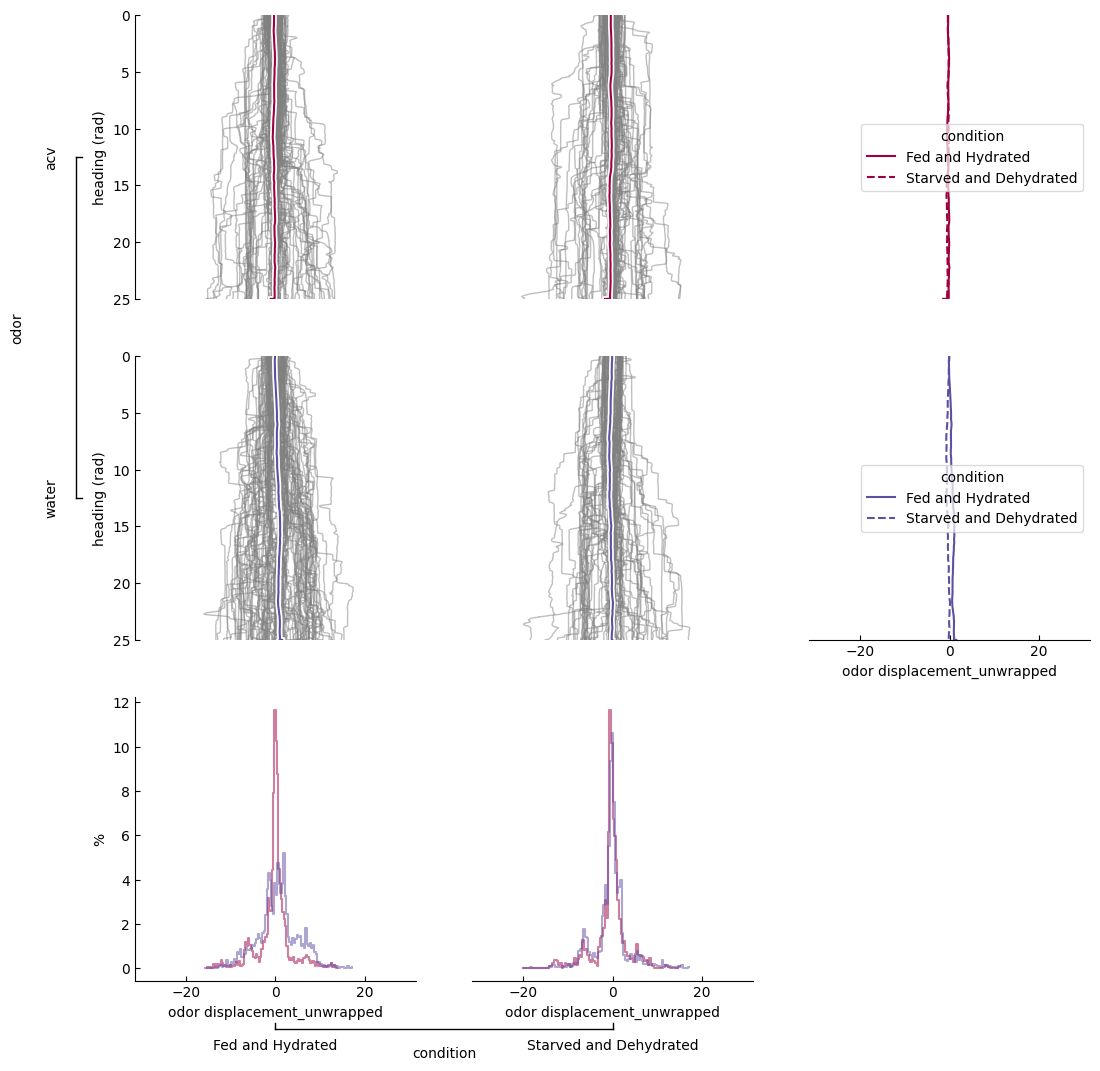

In [3]:
from functools import partial
import scipy
exp.unwrap(key='odor displacement')
exp.plot('odor displacement_unwrapped', 'time',
         col_var='condition', row_var='odor',
         row_cmap='Spectral',
         ylabel='heading (rad)',
         xlim=(-10*np.pi, 10*np.pi),
         ylim=(25, 0),
         right_margin_ratio=1,
         bottom_margin='histogram',
         probability=True,
        #  summary_func=partial(scipy.stats.circmean, high=np.pi, low=-np.pi),
         scale=2)
plt.show()

AttributeError: Variable 'camera_heading_unwrapped' not found in dataset or computed attributes.

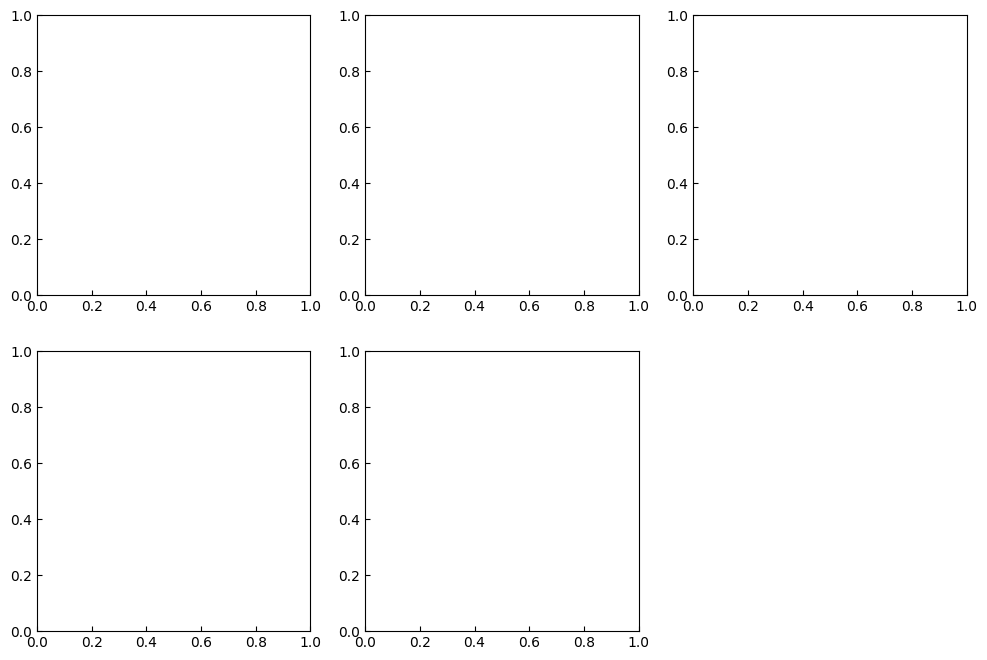

In [4]:
# With right and bottom margin histograms, degree-converted x-axis,
# and a mean ± CI overlay
exp.plot('camera_heading_unwrapped', 'time',
         col_var='condition', row_var=None,
         col_cmap='Spectral',
         right_margin=True, bottom_margin=True,
         confidence_interval=True, n_boot=200,
        #  summary_func=partial(scipy.stats.circmean, high=np.pi, low=-np.pi),
         ylabel='heading (rad)',
         scale=2)
plt.show()

## 3  `plot_type='histogram'`

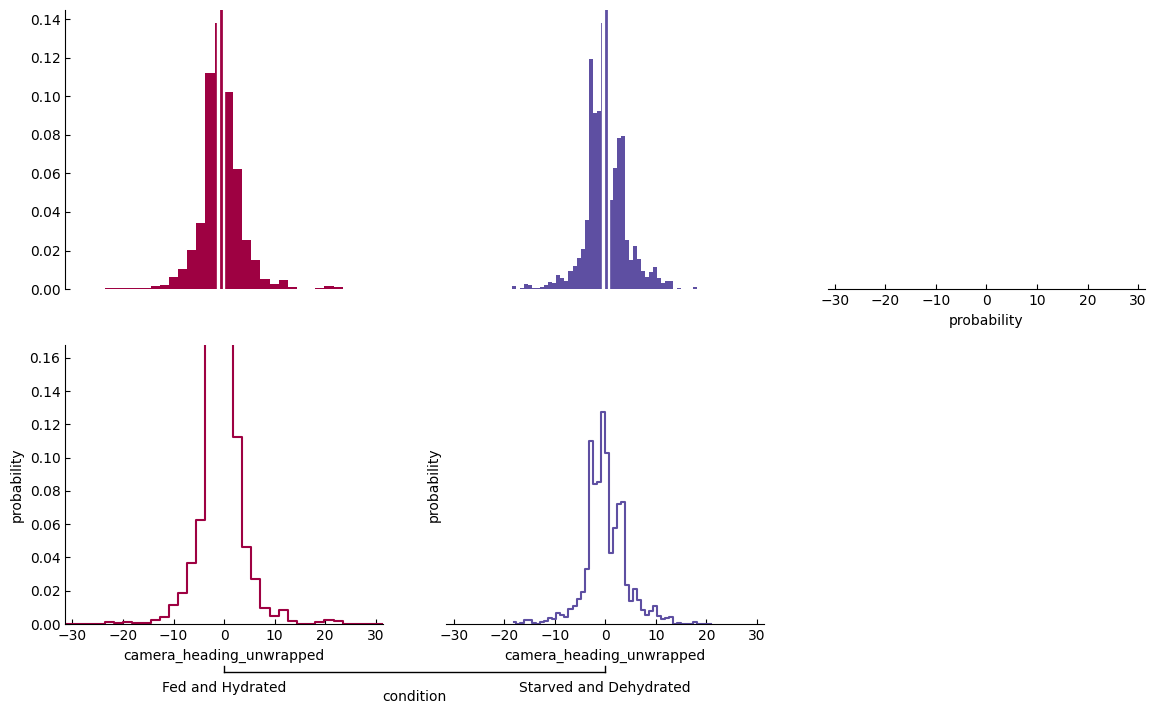

In [ ]:
exp.plot('camera_heading_unwrapped',
         col_var='condition', row_var=None,
         plot_type='histogram',
         probability=True,
         xlim=(-10*np.pi, 10*np.pi),
         col_cmap='Spectral',
         bins=50,
         scale=2)
plt.show()

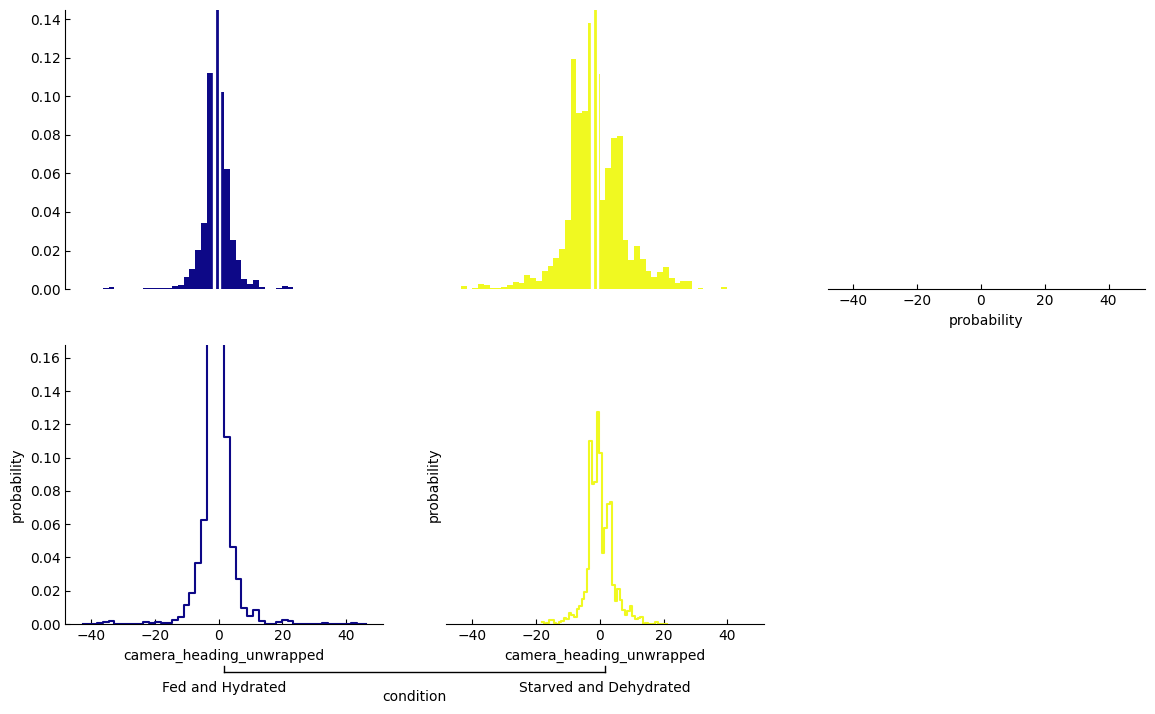

In [ ]:
# probability=True normalises each histogram to sum to 1
exp.plot('camera_heading_unwrapped',
         col_var='condition', row_var=None,
         plot_type='histogram',
         col_cmap='plasma',
         probability=True, bins=50,
         scale=2)
plt.show()

## 4  `plot_type='hist2d'` and `plot_type='scatter'`

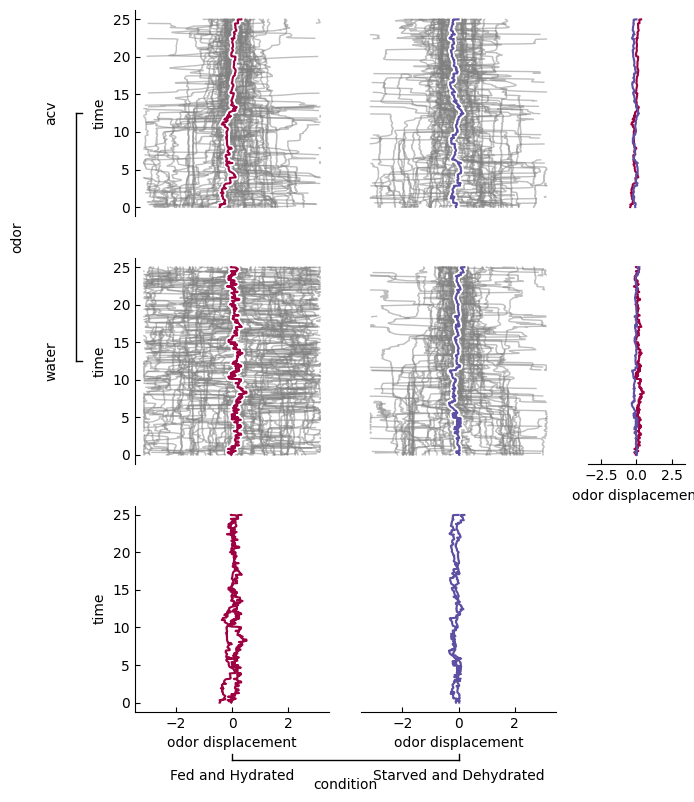

In [ ]:
# 2D histogram: heading (x) vs time (y)
exp.plot('odor displacement', 'time',
         subset={'texture': 'stripes'},
         col_var='condition', row_var='odor',
         right_margin_ratio=.5,
         plot_type='line',
         col_cmap='Spectral',
         bins=21,
         scale=1.5)
plt.show()

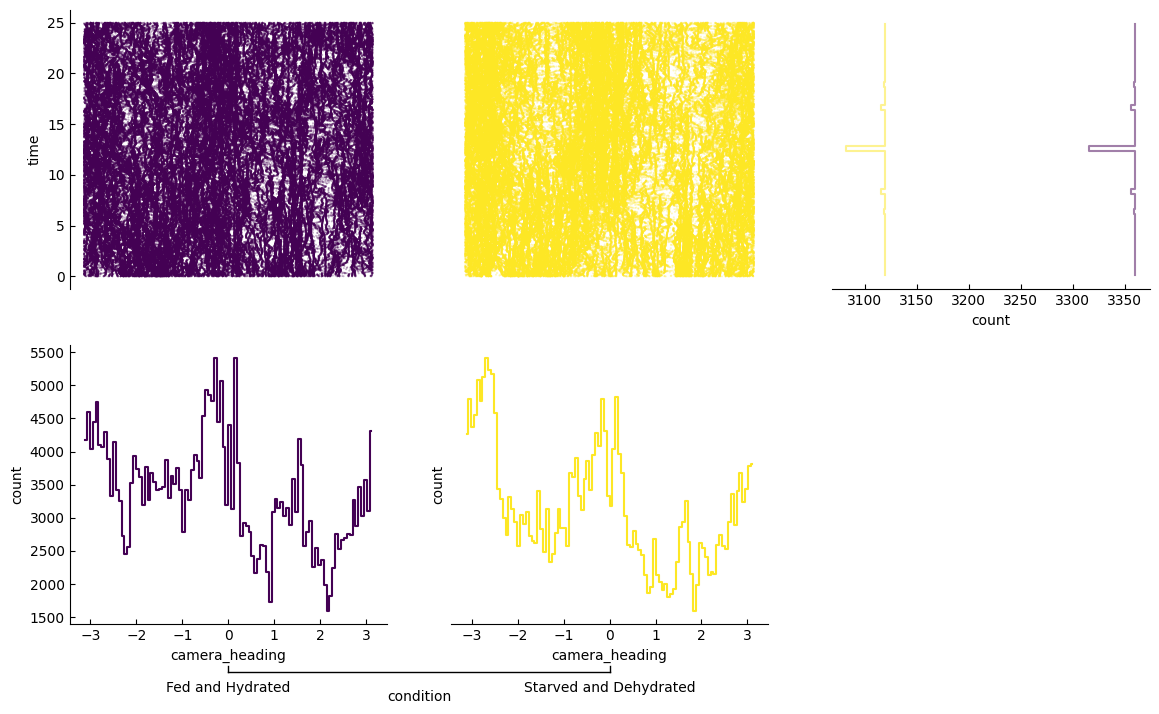

In [ ]:
# Scatter: same data, for comparison — note jitter is applied to x
exp.plot('camera_heading', 'time',
         col_var='condition', row_var=None,
         plot_type='scatter',
         col_cmap='viridis',
         plot_kwargs={'jitter_std': 0.00, 'alpha': 0.3, 's': 2},
         scale=2)
plt.show()

## 5  `plot_type='trajectory2d'`

The heading trace is accumulated into a 2D path.  Optional overlays:
- `circle=True` — per-fly radius circles
- `contour=True` — bootstrap confidence ellipse for endpoint cloud
- `circ_hist=True` — ring histogram of endpoint angles
- `mean_line=True` — mean 2D trajectory

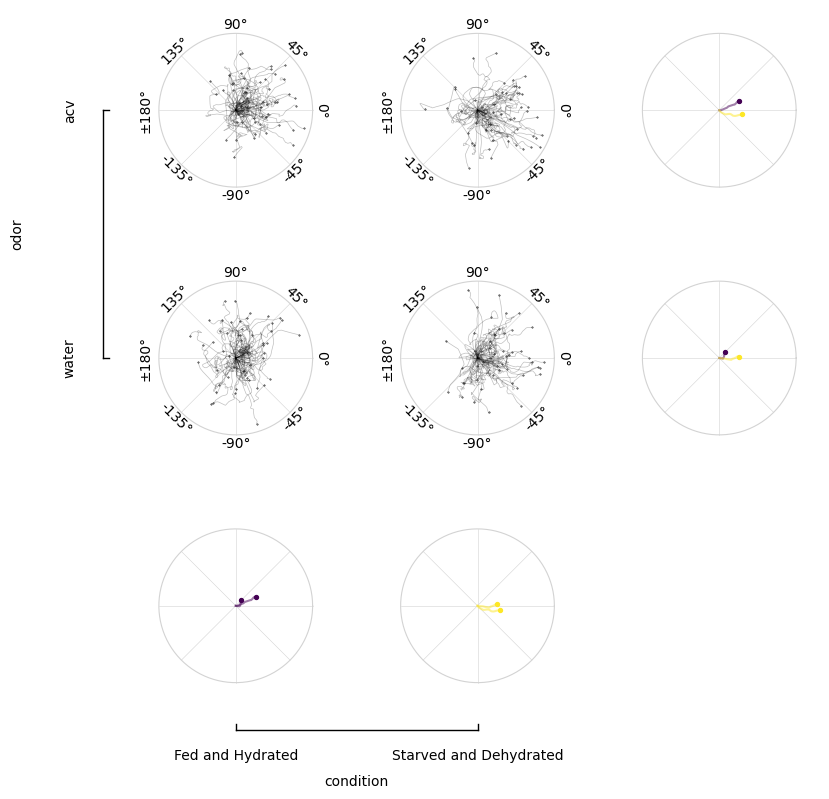

In [ ]:
exp.plot('odor displacement_unwrapped', 'time',
         col_var='condition', row_var='odor',
         plot_type='trajectory2d',
         subset={'texture': 'uniform'},
         col_cmap='viridis',
         scale=1.5)
plt.show()

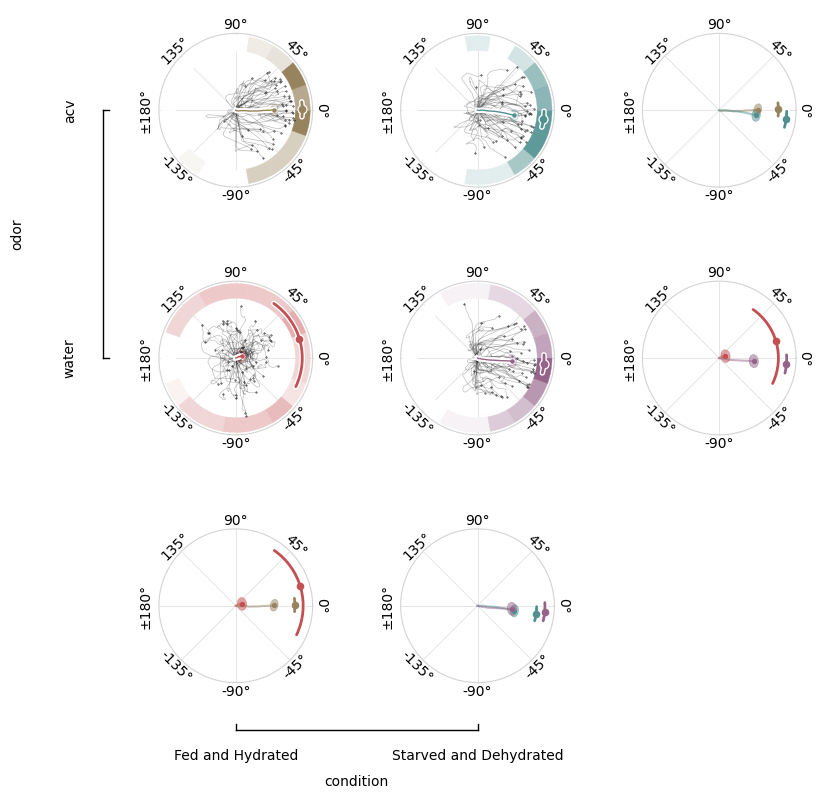

In [ ]:
from magno_tracker.tracking import *

# With all overlays enabled
exp.plot('odor displacement', 'time',
         col_var='condition', row_var='odor',
         plot_type='trajectory2d',
         col_cmap=[red, blue],
         row_cmap=[green, red],
         subset={'texture': 'stripes'},
         right_margin=True,
         plot_kwargs={'circle': False, 'contour': True,
                      'circ_hist': True, 'mean_line': True, 
                      'bins': 18},
         scale=2, subplot_size=(3, 3))
plt.show()

## 6  Saccade traces — `object='saccade', plot_type='line'`

Each trace is a single saccade's heading time-series, time-locked to a
reference frame (`relative_to='start'`, `'peak'`, or `'stop'`).

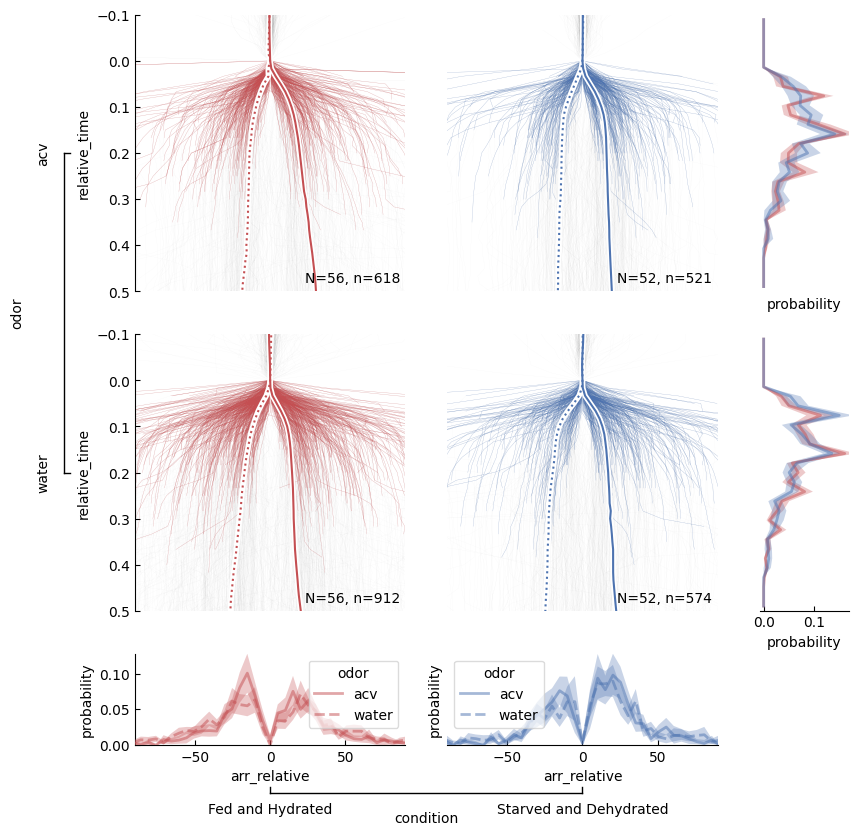

In [ ]:
from magno_tracker.tracking import *

# Saccade traces with per-fly pdf margins.
#
# groupby='fly_id'      → thin lines = one per-fly MEAN trace (2 per fly when
#                          split_by_sign=True: positive and negative averaged
#                          separately within each fly).
# groupby=None          → thin lines = one per individual saccade (default).
#
# margin_groupby='fly_id' → pdf margin: pool saccades per fly → one normalised
#                            histogram per fly → mean ± CI across flies.
# margin_groupby=None     → pdf margin: pool saccades per trial object (default).
#
# The two params are independent: e.g. groupby=None + margin_groupby='fly_id'
# shows every raw saccade as a thin line but computes the marginal pdf per fly.
exp.plot('arr_relative', 'relative_time',
         object='saccade', plot_type='line',
         col_var='condition', row_var='odor',
         col_cmap=[red, blue], row_cmap=None,
         subset={'texture': 'stripes'},
         bottom_margin='pdf',
         right_margin='pdf',
         rad2deg=True,
         ylim=(.5, -.1),
         xlim=(-90, 90),
         probability=True,
         relative_to='start',
         show_n=True,
         groupby=None,          # thin lines = per-fly mean traces
         agg_func=np.nanmean,
         margin_groupby='fly_id',   # pdf margin groups saccades by fly
         scale=2, plot_kwargs={'alpha': .1, 'lw': 0.1, 'split_by_sign': True},
         right_margin_bins=np.linspace(-.10, .50, 30), right_margin_ratio=.33,
         bottom_margin_bins=np.linspace(-180, 180, 72), bottom_margin_ratio=.33)
plt.show()


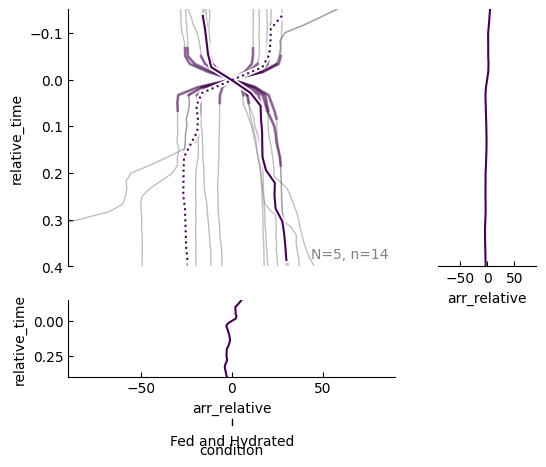

In [ ]:
# Aligned to peak, converted to degrees, with binned mean and sign split
exp.plot('arr_relative', 'relative_time',
         object='saccade', plot_type='line',
         col_var='condition', row_var=None,
         col_cmap='viridis',
         relative_to='peak',
         rad2deg=True,
         xlim=(-90, 90),
         ylim=(0.4, -0.15),
         show_n=True,
         plot_kwargs={'mean_bins': 20, 'split_by_sign': True},
         scale=2)
plt.show()

## 7  Saccade dynamics — `object='saccade', plot_type='hist2d'`

Start angle (position) vs. saccade amplitude: the classic position-magnitude
2D histogram used to characterise saccade control.

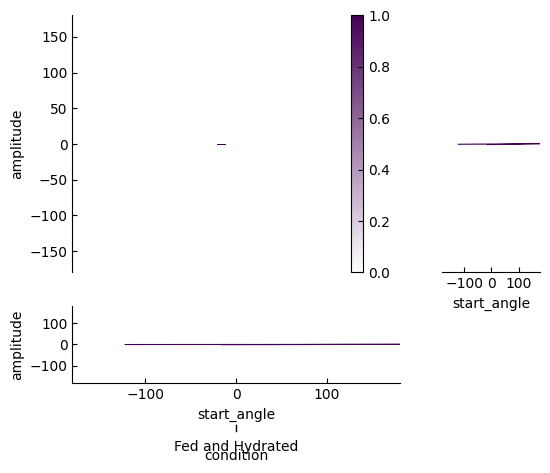

In [ ]:
exp.plot('start_angle', 'amplitude',
         object='saccade', plot_type='hist2d',
         col_var='condition', row_var=None,
         col_cmap='viridis',
         rad2deg=True,
         xlim=(-180, 180),
         ylim=(-180, 180),
         bins=40,
         scale=2)
plt.show()

## 8  Main sequence analysis

`main_sequence_analysis()` draws a fixed 3×2 figure showing:
- magnitude vs duration (scatter + CI strip)
- magnitude vs peak speed (scatter + CI strip)
- magnitude distribution (horizontal CI strip)

All x-axes share a log scale in degrees.

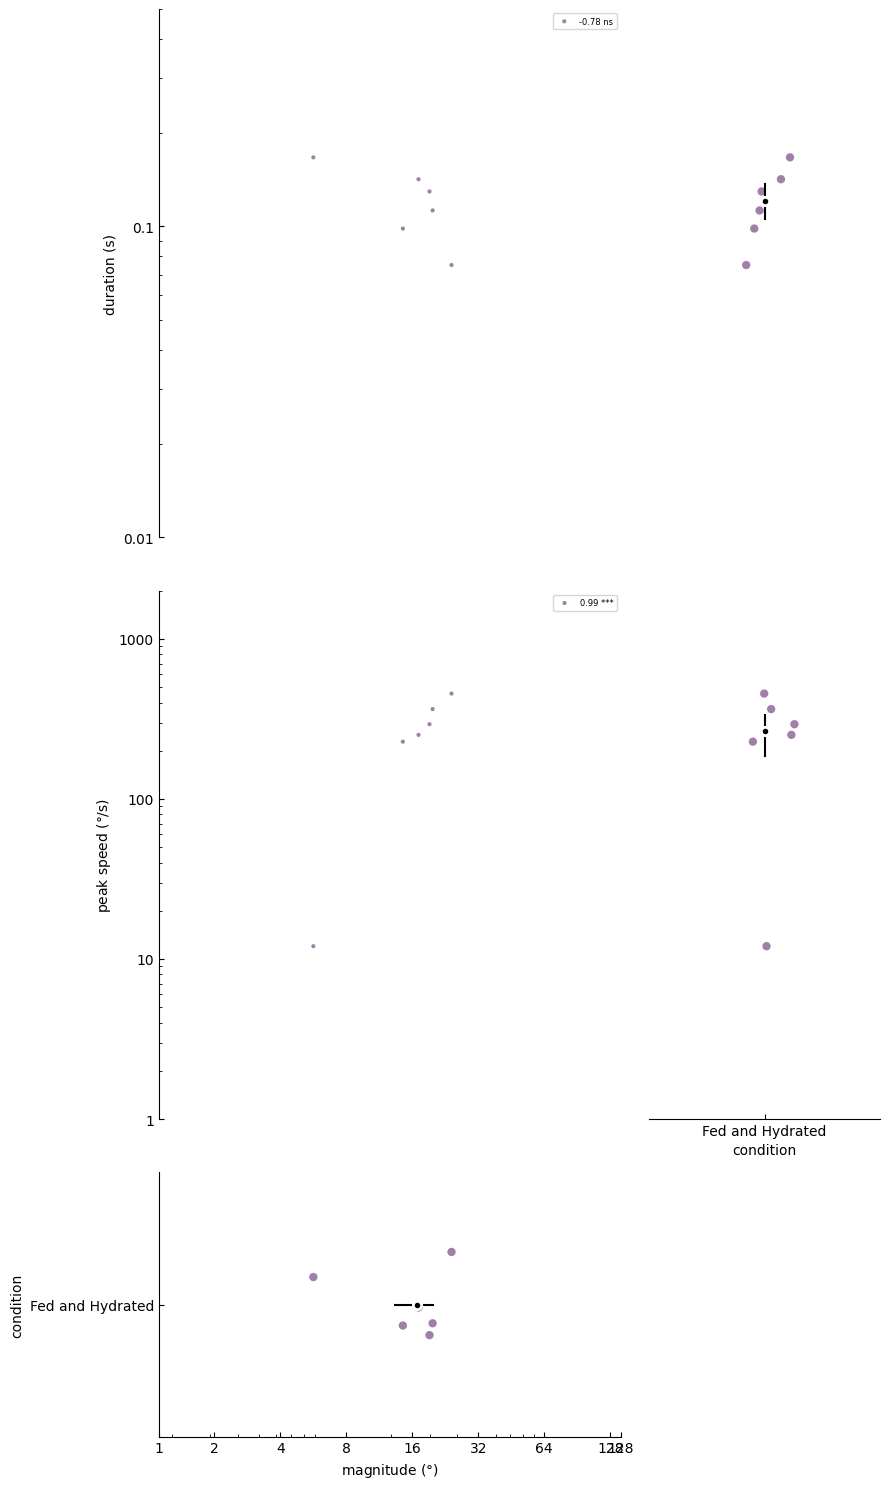

In [ ]:
exp.main_sequence_analysis(group_var='condition',
                            cmap='viridis',
                            scale=3,
                            n_boot=200)
plt.show()

## 9  Margin customisation

Use `right_margin_xlim`, `bottom_margin_ylim` to override auto-synced limits,
or pass explicit margin types as strings.

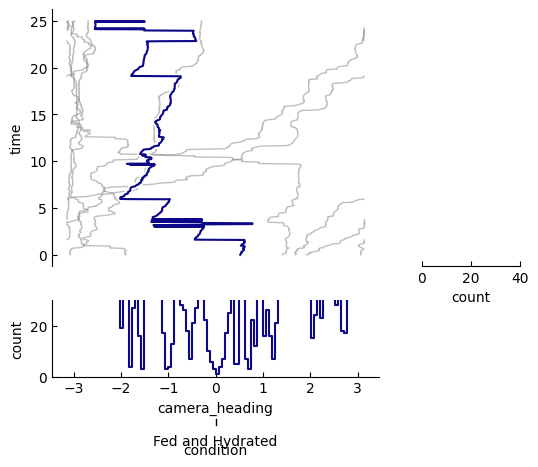

In [ ]:
# Explicit margin types + limit overrides
exp.plot('camera_heading', 'time',
         col_var='condition', row_var=None,
         col_cmap='plasma',
         right_margin='histogram',
         bottom_margin='histogram',
         right_margin_xlim=(0, 40),
         bottom_margin_ylim=(0, 30),
         scale=2)
plt.show()